# House Prices Dataset

This notebook uses the Kaggle House Prices dataset to demonstrate feature engineering, missing value imputation, and data preparation techniques.
The goal is to prepare data for regression modeling and explain each step with intuition, pros/cons, and evaluation ideas.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# pandas: data manipulation and table operations
# seaborn: statistical plotting built on matplotlib
# matplotlib: low-level plotting control and figure management


In [2]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")
# Load the training dataset from the Kaggle competition folder.


In [4]:
print(df.shape)
# Show the number of rows and columns so we can confirm the dataset loaded correctly.


(1460, 81)


In [4]:
df.head()
# Inspect the first few rows to verify feature names and get a sense of the raw data.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Feature engineering

Feature engineering means creating, selecting, or transforming variables so that a model can learn patterns more effectively.
This is a crucial step before applying machine learning models.
Features are columns (your X variables). In Feature Engg, you prepare your data to be fed to ML models.
You drop unnecessary columns, perform imputation for missing values, handle imbalance data, outliers, scaling, encoding and column selection etc.
Feature Engg is a process of using domain knowledge to select, transform and create new features(columns) from raw data


# PART1- DROP COLUMNS

In [5]:
# Drop irrelevant columns.
# 'Id' is a unique identifier and does not carry predictive information about house price.
df = df.drop(columns=['Id'], errors='ignore')


In [7]:
df.head(1)
# Confirm the Id column is removed and inspect the first row after cleaning.


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


#### Handling missing data- Drop columns with many missing data, imputation will be a lot of guess/appromiations for them

Missing values are common in real-world datasets.
Handling them carefully can prevent bias, preserve patterns, and improve model performance.


In [11]:
print(df.isnull())
print("\n")
print(df.isnull().sum())
# Check for missing values in the dataset. The first print shows a boolean mask of missing values, and the second print summarizes the count of missing values per column.
# second part gives a series with column names as index and count of missing values as values, which helps identify which features have missing data and how many entries are affected.

      MSSubClass  MSZoning  LotFrontage  LotArea  Street  Alley  LotShape  \
0          False     False        False    False   False   True     False   
1          False     False        False    False   False   True     False   
2          False     False        False    False   False   True     False   
3          False     False        False    False   False   True     False   
4          False     False        False    False   False   True     False   
...          ...       ...          ...      ...     ...    ...       ...   
1455       False     False        False    False   False   True     False   
1456       False     False        False    False   False   True     False   
1457       False     False        False    False   False   True     False   
1458       False     False        False    False   False   True     False   
1459       False     False        False    False   False   True     False   

      LandContour  Utilities  LotConfig  ...  PoolArea  PoolQC  Fence  \
0 

In [12]:
# Check how many missing values exist per column.
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)
# Sort to identify the most problematic columns first.


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [13]:
missing_percentage = df.isnull().mean().sort_values(ascending=False) 
# Calculate the percentage of missing values for each column and sort them to understand the
# extent of missing data relative to the total number of rows.
missing_percentage

# Use percentage of missing values to decide whether to impute or drop features.


PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
MasVnrType       0.597260
                   ...   
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
SalePrice        0.000000
Length: 80, dtype: float64

In [14]:
threshold = 0.65
missing_percentage[missing_percentage > threshold] 
# this is a series with column names as index and percentage of missing values as values,
# filtered to show only those columns where the percentage exceeds the defined threshold. This helps identify which features have too much missing data and may need to be dropped from the analysis.

PoolQC         0.995205
MiscFeature    0.963014
Alley          0.937671
Fence          0.807534
dtype: float64

In [15]:
# Drop columns with too many missing values.
threshold = 0.65
# If more than 65% of values are missing, the feature is usually too sparse to impute reliably.
columns_with_high_null_values = missing_percentage[missing_percentage > threshold].index.tolist()


In [16]:
columns_with_high_null_values
# Review the list of columns that are candidates for removal.


['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [17]:
df_dropcol_manyMissing = df.drop(columns=columns_with_high_null_values, errors='ignore')
# Remove sparse columns to simplify later imputation and reduce noise.


In [18]:
print(df_dropcol_manyMissing.shape)
# Check how the dataset size changed after dropping high-missing columns.


(1460, 76)


#### Drop columns with low correlations from target variable

In [19]:
import numpy as np
# numpy is used here for numerical calculations and array operations.


In [22]:
# Break the expression into steps and explain each part

# 1) df_dropcol_manyMissing.dtypes
#    -> returns a pandas Series where index = column names and values = dtype of each column.
# dtypes_series = df_dropcol_manyMissing.dtypes

# 2) .to_frame('dtype')
#    -> converts the Series into a DataFrame with a single column named 'dtype';
#       the original Series index (column names) becomes the DataFrame index.
# dtype_df = dtypes_series.to_frame('dtype')

# 3) .reset_index()
#    -> moves the current index (which holds the original column names) into a regular column called 'index'
#       and replaces the index with a default integer RangeIndex.
# dtype_df_reset = dtype_df.reset_index()

# 4) .rename(columns={'index':'column'})
#    -> renames the 'index' column to 'column' for clearer semantics (column name, dtype).
# result = dtype_df_reset.rename(columns={'index': 'column'})

# Show data type for each column in df_dropcol_manyMissing
df_dropcol_manyMissing.dtypes.to_frame('dtype').reset_index().rename(columns={'index':'column'})

,column,dtype
0,MSSubClass,int64
1,MSZoning,str
2,LotFrontage,float64
3,LotArea,int64
4,Street,str
...,...,...
71,MoSold,int64
72,YrSold,int64
73,SaleType,str
74,SaleCondition,str


In [24]:
df_dropcol_manyMissing.select_dtypes(include=[np.number]) 
# Select only numeric columns for correlation analysis, as correlation is not meaningful for categorical data.

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,366,0,112,0,0,0,0,4,2010,142125


In [28]:
# Break down the expression step by step:

# 1) df_dropcol_manyMissing.select_dtypes(include=[np.number])
#    -> Filters the dataframe to keep only numeric columns (int, float, etc.)
#       Returns a dataframe with only numeric data types

# 2) .corr()
#    -> Computes the correlation matrix for all numeric columns
#       Returns a square dataframe where rows and columns are numeric features
#       Each cell [i,j] shows correlation between feature i and feature j

# 3) ['SalePrice']
#    -> Extracts the correlation values for the 'SalePrice' column
#       Returns a pandas Series where index = feature names and values = correlation with SalePrice
#       Positive values = features that increase with SalePrice
#       Negative values = features that decrease with SalePrice
#       Values near 0 = weak relationship with SalePrice

# Overall: This shows how strongly each numeric feature is correlated with the target variable (SalePrice)

df_dropcol_manyMissing.select_dtypes(include=[np.number]).corr()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


In [31]:
df_dropcol_manyMissing.select_dtypes(include=[np.number]).corr()['SalePrice'].to_frame() # covert to data frame

,SalePrice
MSSubClass,-0.084284
LotFrontage,0.351799
LotArea,0.263843
OverallQual,0.790982
OverallCond,-0.077856
YearBuilt,0.522897
YearRemodAdd,0.507101
MasVnrArea,0.477493
BsmtFinSF1,0.386420
BsmtFinSF2,-0.011378


In [33]:
df_dropcol_manyMissing.select_dtypes(include=[np.number]).corr()['SalePrice']

MSSubClass      -0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond     -0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2      -0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF    -0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath    -0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch   -0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal         -0.021190
MoSold           0.046432
YrSold          -0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [34]:
# Filter by importance using correlation with the target variable.
# We use absolute correlation because we are interested in both strong positive and negative relationships.
# Negative correlation means that the direction of the relationship is inverse, but it can still be a strong predictor.
target_coorelation = df_dropcol_manyMissing.select_dtypes(include=[np.number]).corr()['SalePrice'].abs()


In [35]:
target_coorelation
# View which numeric features have the strongest direct relationship with SalePrice.


MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [36]:
low_imapct_threshold = 0.1

# Interview note: correlation measures standardized relationship, while covariance depends on scale.
# Correlation is preferred for feature selection because it is comparable across variables.
# Remove features with very low correlation to the target, since they are unlikely to impact the target variable significantly.
# This helps simplify the model and reduce noise from irrelevant features.
low_impact_cols = target_coorelation[target_coorelation < low_imapct_threshold].index.to_list()
low_impact_cols


['MSSubClass',
 'OverallCond',
 'BsmtFinSF2',
 'LowQualFinSF',
 'BsmtHalfBath',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [38]:
df_drop_manyMissing_lowCorrWithTarget = df_dropcol_manyMissing.drop(columns=low_impact_cols, errors='ignore')
# Drop low-impact features to simplify the dataset and reduce noise.


In [39]:
df_drop_manyMissing_lowCorrWithTarget.shape
# Check the dataset shape after removing low-impact features.


(1460, 66)

#### Drop columns having high correlation among themselves i.e. remove multicollinearity

In [41]:
# Removing multi-collinearity
# Highly correlated input features can distort model training and inflate coefficient variance.
corr_matrix = df_drop_manyMissing_lowCorrWithTarget.select_dtypes(include=[np.number]).corr().abs()

corr_matrix


,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
LotFrontage,1.000000,0.426095,0.251646,0.123349,0.088866,0.193458,0.233633,0.132644,0.392075,0.457181,...,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.041383,0.351799
LotArea,0.426095,1.000000,0.105806,0.014228,0.013788,0.104160,0.214103,0.002618,0.260833,0.299475,...,0.190015,0.271364,0.024947,0.154871,0.180403,0.171698,0.084774,0.018340,0.043160,0.263843
OverallQual,0.251646,0.105806,1.000000,0.572323,0.550684,0.411876,0.239666,0.308159,0.537808,0.476224,...,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,0.113937,0.064886,0.790982
YearBuilt,0.123349,0.014228,0.572323,1.000000,0.592855,0.315707,0.249503,0.149040,0.391452,0.281986,...,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,0.387268,0.050364,0.522897
YearRemodAdd,0.088866,0.013788,0.550684,0.592855,1.000000,0.179618,0.128451,0.181133,0.291066,0.240379,...,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,0.193919,0.038740,0.507101
MasVnrArea,0.193458,0.104160,0.411876,0.315707,0.179618,1.000000,0.264736,0.114442,0.363936,0.344501,...,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,0.110204,0.061466,0.477493
BsmtFinSF1,0.233633,0.214103,0.239666,0.249503,0.128451,0.264736,1.000000,0.495251,0.522396,0.445863,...,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,0.102303,0.062021,0.386420
BsmtUnfSF,0.132644,0.002618,0.308159,0.149040,0.181133,0.114442,0.495251,1.000000,0.415360,0.317987,...,0.250647,0.051575,0.190708,0.214175,0.183303,0.005316,0.129005,0.002538,0.012579,0.214479
TotalBsmtSF,0.392075,0.260833,0.537808,0.391452,0.291066,0.363936,0.522396,0.415360,1.000000,0.819530,...,0.285573,0.339519,0.322445,0.434585,0.486665,0.232019,0.247264,0.095478,0.084489,0.613581
1stFlrSF,0.457181,0.299475,0.476224,0.281986,0.240379,0.344501,0.445863,0.317987,0.819530,1.000000,...,0.409516,0.410531,0.233449,0.439317,0.489782,0.235459,0.211671,0.065292,0.088758,0.605852


In [42]:
np.ones(corr_matrix.shape)
# Create a matrix of ones with the same shape as the correlation matrix, which will be used to create a mask for the upper triangle of the correlation matrix.

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],


In [44]:
# correlation matrix is symmetric, so we only need to consider the upper triangle of the matrix to avoid duplicate comparisons.
# Create a mask for the upper triangle of the correlation matrix to avoid duplicate comparisons.
np.triu(np.ones(corr_matrix.shape), k=1)
# this will give us a boolean mask where the upper triangle (excluding the diagonal) is 1 and the rest is 0,
# which we can use to filter the correlation matrix and identify pairs of features that are highly correlated with each other.
np.triu(np.ones(corr_matrix.shape), k=1).astype(bool) # Convert the mask to boolean type for easier indexing when filtering the correlation matrix.



array([[False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
  

In [45]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Keep only one half of the matrix, so each correlated pair is considered once.
upper


,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
LotFrontage,NaN,0.426095,0.251646,0.123349,0.088866,0.193458,0.233633,0.132644,0.392075,0.457181,...,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.041383,0.351799
LotArea,NaN,NaN,0.105806,0.014228,0.013788,0.104160,0.214103,0.002618,0.260833,0.299475,...,0.190015,0.271364,0.024947,0.154871,0.180403,0.171698,0.084774,0.018340,0.043160,0.263843
OverallQual,NaN,NaN,NaN,0.572323,0.550684,0.411876,0.239666,0.308159,0.537808,0.476224,...,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,0.113937,0.064886,0.790982
YearBuilt,NaN,NaN,NaN,NaN,0.592855,0.315707,0.249503,0.149040,0.391452,0.281986,...,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,0.387268,0.050364,0.522897
YearRemodAdd,NaN,NaN,NaN,NaN,NaN,0.179618,0.128451,0.181133,0.291066,0.240379,...,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,0.193919,0.038740,0.507101
MasVnrArea,NaN,NaN,NaN,NaN,NaN,NaN,0.264736,0.114442,0.363936,0.344501,...,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,0.110204,0.061466,0.477493
BsmtFinSF1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495251,0.522396,0.445863,...,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,0.102303,0.062021,0.386420
BsmtUnfSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415360,0.317987,...,0.250647,0.051575,0.190708,0.214175,0.183303,0.005316,0.129005,0.002538,0.012579,0.214479
TotalBsmtSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.819530,...,0.285573,0.339519,0.322445,0.434585,0.486665,0.232019,0.247264,0.095478,0.084489,0.613581
1stFlrSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.409516,0.410531,0.233449,0.439317,0.489782,0.235459,0.211671,0.065292,0.088758,0.605852


In [53]:
upper.columns
# Display feature names so we know which columns are being compared.
# columns with numeric values only are included in the correlation matrix, 
# thus number of columns in the correlation matrix may be less than total columns in the dataset.


Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [58]:

#Standard Protocol: In data science, when two features are highly collinear, the standard rule of thumb is to discard the feature with the weaker individual correlation to the target.

#Other Factors to ConsiderBefore making the final deletion, quickly check these three practical data aspects:
#Missing Values: If Y has a high percentage of missing data, keeping X might be better.
#Data Collection Cost: If Y is significantly more expensive or difficult to collect than X, X might be preferred.
#Feature Interpretability: If X is a direct, easily understood metric and Y is a complex transformation, X might be better for business stakeholders.

redundant_cols = [column for column in upper.columns if any(upper[column] > 0.8)]
print(redundant_cols)

# Remove redundant columns with very high pairwise correlation (>0.8).
# This threshold is common, but can vary depending on the dataset and model.


['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']


In [59]:
# Choose which feature to drop among highly correlated pairs by keeping the one with higher
# absolute correlation to the target (target_coorelation). Works with `upper` and
# df_drop_manyMissing_lowCorrWithTarget` already in the notebook.

# ensure df_2 exists for downstream cells
df_test = df_drop_manyMissing_lowCorrWithTarget.copy()

to_drop = set()
for i in upper.index:
    for j in upper.columns:
        corr_ij = upper.loc[i, j]
        if pd.notna(corr_ij) and abs(corr_ij) > 0.8:
            # if you just want the value and not default then,
            # target_coorelation[i] and target_coorelation[j] will give you the absolute correlation of feature i and j with the target variable SalePrice, respectively.
            corr_i = target_coorelation.get(i, 0) # gets the absolute correlation of feature i with the target variable SalePrice, defaulting to 0 if not found.
            corr_j = target_coorelation.get(j, 0) # gets the absolute correlation of feature j with the target variable SalePrice, defaulting to 0 if not found.
            # drop the column with lower absolute correlation to target
            if corr_i >= corr_j:
                to_drop.add(j)
            else:
                to_drop.add(i)

to_drop = sorted(to_drop)
print("Dropping columns due to multicollinearity (kept higher corr w/ target):", to_drop)

df_test_droppedMulti = df_test.drop(columns=to_drop, errors='ignore')
print("df_test_droppedMulti.shape ->", df_test_droppedMulti.shape)

Dropping columns due to multicollinearity (kept higher corr w/ target): ['1stFlrSF', 'GarageArea', 'GarageYrBlt', 'TotRmsAbvGrd']
df_test_droppedMulti.shape -> (1460, 62)


In [60]:
df_drop_manyMissing_lowCorrWithTarget_MultiColl = df_drop_manyMissing_lowCorrWithTarget.drop(columns=redundant_cols, errors='ignore')
# Drop one feature from each highly correlated pair to reduce multicollinearity.


In [61]:
df_drop_manyMissing_lowCorrWithTarget_MultiColl.shape
# Inspect the final dataset shape after feature selection and redundancy removal.


(1460, 62)

# Part-2 Handling Missing Data via Imputation

Continue with missing value imputation techniques and comparisons.
We will compare simple, model-based, and iterative imputation approaches.

Useful links- https://www.kaggle.com/code/azminetoushikwasi/all-imputation-techniques-with-pros-and-cons


In [100]:
df_drop_manyMissing_lowCorrWithTarget_MultiColl.info()
# Review data types and remaining missing values after feature selection.


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   str    
 4   LotShape       1460 non-null   str    
 5   LandContour    1460 non-null   str    
 6   Utilities      1460 non-null   str    
 7   LotConfig      1460 non-null   str    
 8   LandSlope      1460 non-null   str    
 9   Neighborhood   1460 non-null   str    
 10  Condition1     1460 non-null   str    
 11  Condition2     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  YearBuilt      1460 non-null   int64  
 16  YearRemodAdd   1460 non-null   int64  
 17  RoofStyle      1460 non-null   str    
 18  RoofMatl       1460

In [65]:
df_drop_manyMissing_lowCorrWithTarget_MultiColl.isnull().sum()
# Check for any remaining missing values in the final dataset after all feature selection steps.

MSZoning           0
LotFrontage      259
LotArea            0
Street             0
LotShape           0
                ... 
EnclosedPorch      0
ScreenPorch        0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 62, dtype: int64

In [67]:
missing_values = df_drop_manyMissing_lowCorrWithTarget_MultiColl.isnull().sum() # series with column names as index and count of missing values as values
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
# Identify columns that still contain missing values for imputation.
missing_values


MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageQual       81
GarageFinish     81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtQual         37
BsmtFinType1     37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64

#### Simple Imputation

Instead of deleting rows, we can estimate missing values.

- Mean imputation: use for numeric features with roughly symmetric distribution. Use mean if feature/column has no outliers.
- Median imputation: use for numeric features with outliers or skewed distribution. Use median if feature/column has outliers.
- Mode imputation: use for categorical features with a common dominant value.

Pros: easy to implement, preserves dataset size.
Cons: can bias distributions and underestimate variance.


- Mean Imputation:

Mean imputation is a fast and simple method that replaces missing data with the average value of the remaining data. 

It is great for quick, basic tasks. However, it artificially lowers data variance and destroys the relationship between variables, making it risky for accurate machine learning.    
    Pros        
        
        Easy to use: It is very simple to understand and put into code.
    
        Keeps the mean: The overall average of that column stays exactly the same as the original observed data.Keeps sample size: It allows you to keep all your data rows instead of deleting them.
    
        Fast computation: It works instantly, even on very large datasets.

    Cons        
        Lowers variance: Adding the same average value repeatedly crushes the natural spread (variance) of the data.
        
        Adds bias: It creates a false spike in your data distribution exactly at the mean.
        
        Ignores relationships: It treats missing values independently. It ignores clues from other columns that could help guess the missing number.
        
        Destroys correlations: Because imputed values are identical, relationships between different variables become weaker or false.

    When to Use
        Use mean imputation only for quick, basic checks or if less than 5% of your data is missing.

- Meadian Imputation

Median imputation is the process of filling in missing values in a dataset with the middle value of that specific column. It is a fast, simple way to fix incomplete data. However, it can make your data less accurate.

Pros
    
    Stops Outliers from Messing Up Data: The median is the "middle" value. It ignores extreme high or low numbers. This makes it better than mean imputation, which can be thrown off by extreme values.
    
    Fast and Easy: It requires almost no math or computing power. You can apply it to a whole dataset in seconds.
    
    Works Well on Skewed Data: If your data is pushed heavily to one side (skewed), the median gives a better "middle" picture than the average.
    
Cons
    
    Reduces Variation: Replacing many missing spaces with the same exact number makes your data less spread out. This can lead to false confidence in your results.
    
    Ignores Hidden Clues: It completely ignores the relationship between different columns in your data.
    
    Can Create "Spikes": Grouping too many identical values at the median creates an unnatural spike in your data around median.

- Mode Imputation

Mode imputation replaces missing values in a dataset with the most frequent value (the mode). It is almost entirely used for categorical data (like text, colors, or labels).

    Pros
        
        Easy to Use: It is simple to understand, code, and calculate.Keeps Data: It lets you keep the rows with missing data instead of deleting them.
        
        Works for Categories: It is one of the only simple methods that works on categorical data where mean/median do not apply.
        
        No Outlier Issues: The most common value is not changed by extreme or unusual data points.

    Cons
        
        Creates Bias: Because you are filling missing spaces with the same value, it can make that category appear much more common than it truly is.
        
        Reduces Variety: It lowers the natural diversity of your dataset.
        
        ** Ignores Relationships:** It ignores clues from other columns that might help guess a more accurate value.
        
        Worse for Rare Items: If the most frequent value makes up only a tiny part of the data, the imputed data will likely be highly inaccurate.

In [68]:
# Mean imputation replaces missing values with the average.
# It is simple but can pull values towards the mean and shrink variance.
df_mean = df_drop_manyMissing_lowCorrWithTarget_MultiColl.copy()
df_mean.fillna({"LotFrontage": df_mean["LotFrontage"].mean()}, inplace=True)


,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [69]:
# Median imputation replaces missing values with the middle value.
# It is robust to outliers and skewed numeric distributions.
df_median = df_drop_manyMissing_lowCorrWithTarget_MultiColl.copy()
df_median.fillna({"LotFrontage": df_median["LotFrontage"].median()}, inplace=True)


,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [70]:
# Mode imputation is used for categorical variables.
# It replaces missing values with the most frequent category.
df_mode = df_drop_manyMissing_lowCorrWithTarget_MultiColl.copy()


In [71]:
df_mode['GarageType'].unique()
# Inspect the available categories before imputation.
df_mode["GarageType"].mode()[0]
# Find the most frequent GarageType value to use for mode imputation.


<StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

In [73]:
df_mode.fillna({"GarageType": df_mode["GarageType"].mode()[0]}, inplace=True)
# Fill missing GarageType values using the mode.


,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


#### Compare Before and After Imputation

Visualize how different imputation methods affect the feature distribution.


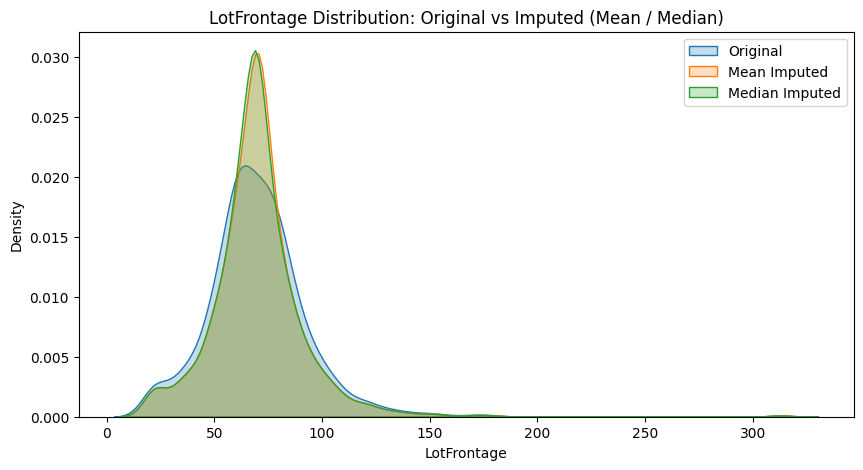

In [74]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median)")
plt.show()
# Compare the effects of mean and median imputation visually.


In [75]:
def compare_imputation(df_before, df_after, column_name):
    # Compare only the rows that were missing originally.
    missing_indices = {
        column_name: df_before[df_before[column_name].isnull()].index.to_list()
        for column_name in df_before.columns
        if df_before[column_name].isnull().any()
    } # captures the indices of rows that had missing values for each column in the original dataframe before imputation.

    print("Missing indices for each column:", missing_indices)  # Debug print to show which indices had missing values

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before": df_before.loc[idx_list, column_name],
        "After": df_after.loc[idx_list, column_name],
    })

    print(f"Changes in column : {column_name}")
    return comparison

# Use this helper to inspect imputed values for specific features.


In [76]:
compare_imputation(df_drop_manyMissing_lowCorrWithTarget_MultiColl, df_mean, "LotFrontage")
# Compare original vs mean imputed values for LotFrontage.

Missing indices for each column: {'LotFrontage': [7, 12, 14, 16, 24, 31, 42, 43, 50, 64, 66, 76, 84, 95, 100, 104, 111, 113, 116, 120, 126, 131, 133, 136, 147, 149, 152, 153, 160, 166, 169, 170, 177, 180, 186, 191, 203, 207, 208, 214, 218, 221, 234, 237, 244, 249, 269, 287, 288, 293, 307, 308, 310, 319, 328, 330, 335, 342, 346, 347, 351, 356, 360, 361, 364, 366, 369, 370, 375, 384, 392, 393, 404, 405, 412, 421, 426, 447, 452, 457, 458, 459, 465, 470, 484, 490, 496, 516, 518, 529, 537, 538, 539, 541, 545, 559, 560, 564, 569, 580, 593, 610, 611, 612, 616, 623, 626, 641, 645, 660, 666, 668, 672, 679, 682, 685, 687, 690, 706, 709, 714, 720, 721, 726, 734, 745, 746, 751, 757, 770, 783, 785, 789, 791, 794, 811, 816, 817, 822, 828, 840, 845, 851, 853, 855, 856, 859, 865, 868, 879, 882, 893, 900, 904, 908, 911, 917, 925, 927, 928, 929, 939, 941, 944, 953, 961, 967, 975, 980, 983, 988, 996, 997, 1003, 1006, 1017, 1018, 1024, 1030, 1032, 1033, 1035, 1037, 1041, 1045, 1057, 1059, 1064, 1077, 1084

,Before,After
7,NaN,70.049958
12,NaN,70.049958
14,NaN,70.049958
16,NaN,70.049958
24,NaN,70.049958
...,...,...
1429,NaN,70.049958
1431,NaN,70.049958
1441,NaN,70.049958
1443,NaN,70.049958


### KNN Imputation

KNN imputation fills missing numeric values using the average of the nearest neighbors.
It can preserve local structure but may be slower on large datasets.
Use it when similar rows should have similar values and numeric predictor data is rich. KNNImputer is applied to numeric columns only.


- K-Nearest Neighbors (KNN) imputation is a multivariate data preprocessing technique that fills in missing values by identifying the K most similar rows in a dataset and averaging their attributes. Popular implementations like scikit-learn's KNNImputer calculate similarities using distance metrics like Euclidean distance to ensure highly localized and contextual data recovery.

Its multivariate because in distance calculation, all the rows and columns which dosn't have NAN are used to calculate distance.
Google quickly to see a small example

- Pros of KNN Imputation

    Captures Relationships: Evaluates multiple features simultaneously to preserve complex correlations between variables.

    Preserves Variance: Avoids the artificial distribution spikes caused by simple mean or median filling.

    No Distribution Assumptions: Works seamlessly on both linear and non-linear data distributions without requiring normality.
    
    Versatile Formatting: Easily adapts to both continuous numerical values and encoded categorical data.
    
    High Predictive Accuracy: Outperforms univariate methods when missing data patterns are heavily structured.
    
- Cons of KNN Imputation

    Computationally Expensive: Requires calculating pairwise distances across the entire dataset for every missing value.
    
    High Memory Footprint: Keeps the complete training dataset in active memory during the entire transformation phase.
    
    Scale Sensitivity: Demands rigorous feature scaling because larger numeric ranges distort distance measurements.
    
    Outlier Vulnerability: Outlying data points skew the distance metrics and degrade the quality of neighbor predictions.
    
    Curse of Dimensionality: Suffers in high-dimensional feature spaces where distances between points collapse and become uniform.
    
- When to Use KNN Imputation

    Moderate Dataset Sizes: Best suited for smaller or mid-sized datasets where computational overhead is manageable.
    
    Missing at Random (MAR): Ideal when missingness is systematically related to other observed variables in the matrix.
    
    Highly Correlated Features: Perfect for domain data like climate logs or customer segmentation where attributes heavily depend on each other.
    
    Downstream Sensitivity: Necessary when accuracy in model building matters far more than preprocessing execution speed.
    

#### 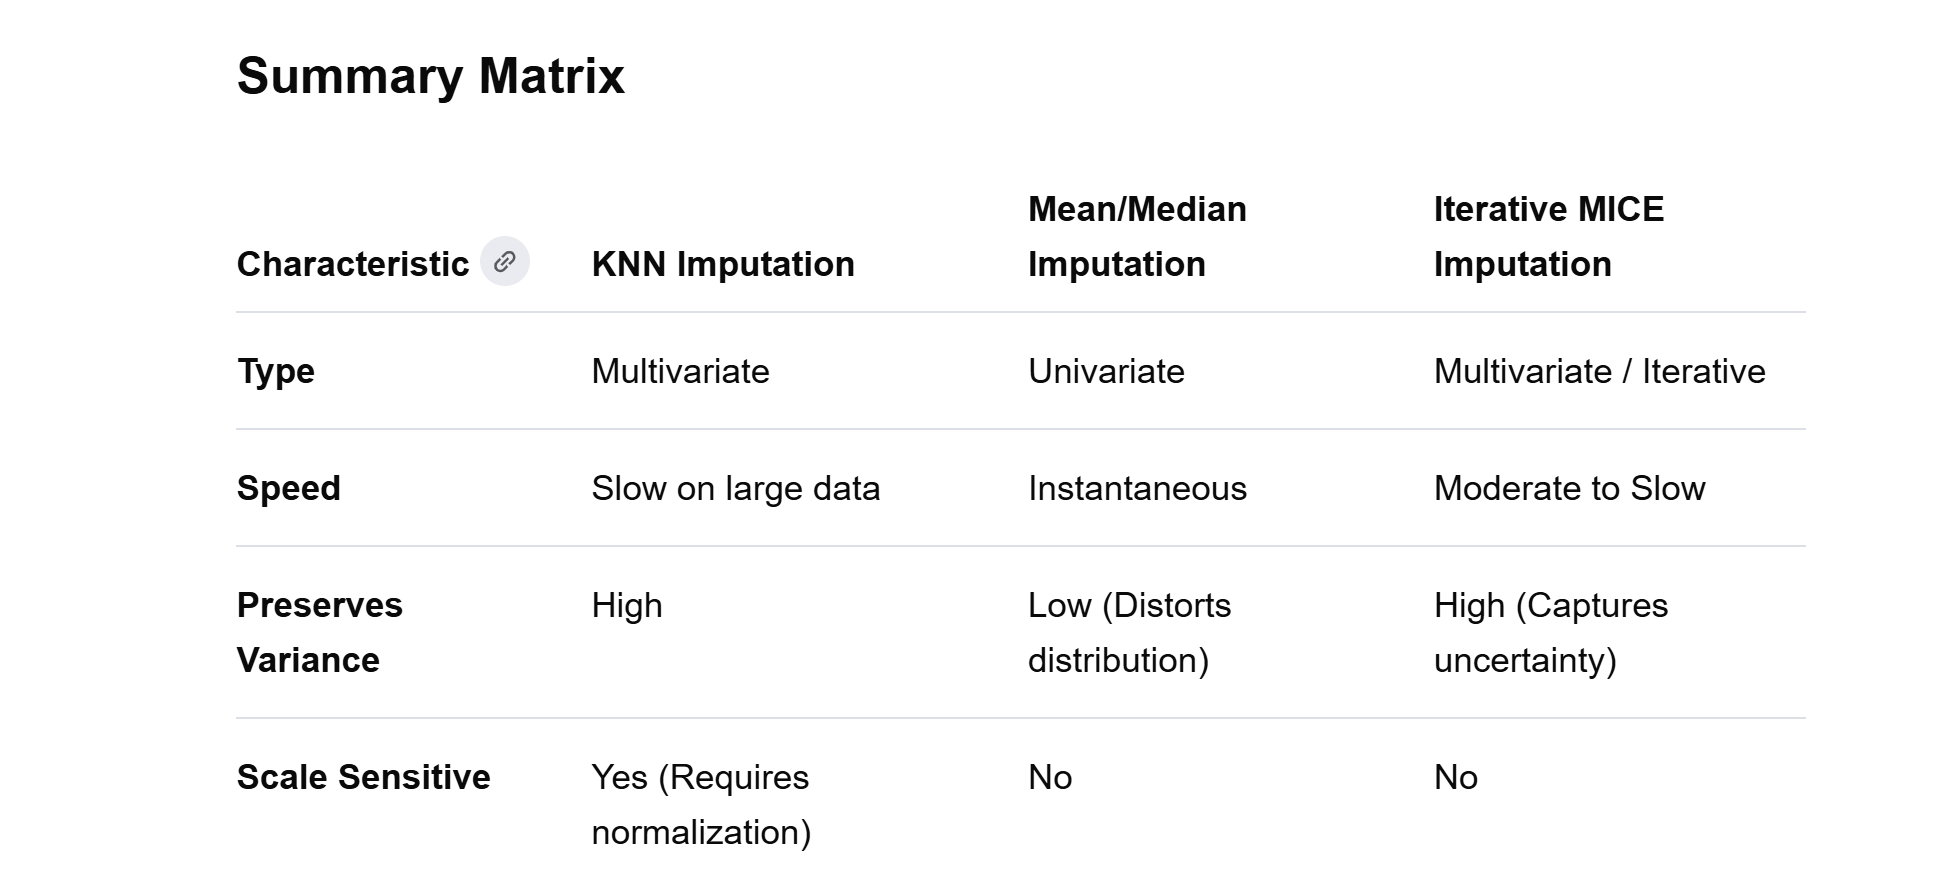

In [77]:
#!pip install scikit-learn # way of calling pip in line in jupyter notebook for installations
# Uncomment if scikit-learn is not installed in your environment.


   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.2 MB 18.4 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.2 MB 16.2 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 14.7 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --- ------------------------------------ 3.4/36.5 MB 16.8 MB/s eta 0:00:02
   ------ --------------------------------- 6.0/36.5 MB 14.8 MB/s eta 0:00:03
   --------- ------------------------------ 8.9/36.5 MB 14.1 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/36.5 MB 13.8 MB/s eta 0:00:02
   --------------- ------------------------ 14.2/36.5 MB 13.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.0/36.5 MB 13.5 MB/s eta 0:00:02
   --------------------- ------------------ 19.7/36.5 MB 13.5 MB/s eta 0:00:02
   ------------------------ --------------- 22.3/36.5 MB 13.4 MB/s eta 0:00:02
   -


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\abhis\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [85]:
from sklearn.impute import KNNImputer
# Import the KNN imputer for numeric feature imputation.


In [86]:
knn_imputer = KNNImputer(n_neighbors=5)
# 5 neighbors is a common default; adjust to trade off local fit and smoothness.


In [89]:
df_knn = df_drop_manyMissing_lowCorrWithTarget_MultiColl.copy()
# Use a copy so we can compare KNN imputation against other methods.


In [92]:
print(df_drop_manyMissing_lowCorrWithTarget_MultiColl.isnull().sum().sort_values(ascending=False))


MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
                ... 
EnclosedPorch      0
ScreenPorch        0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 62, dtype: int64


In [94]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns
numerical_cols
# KNNImputer is applied to numeric columns only.


Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [95]:
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])
# Fit and transform numeric columns using nearest-neighbor based imputation.


In [ ]:
compare_imputation(df_drop_manyMissing_lowCorrWithTarget_MultiColl, df_knn, "LotFrontage").head(10)
# Inspect how KNN imputation filled missing LotFrontage values.


Changes in column : LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
31,NaN,68.4
42,NaN,69.6
43,NaN,70.6
50,NaN,77.8
64,NaN,76.4


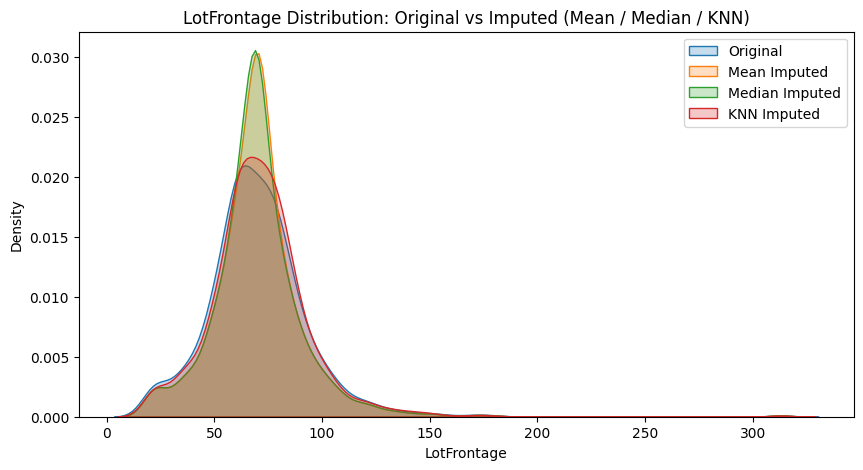

In [98]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()
# Visualize how each imputation method changes the feature distribution.


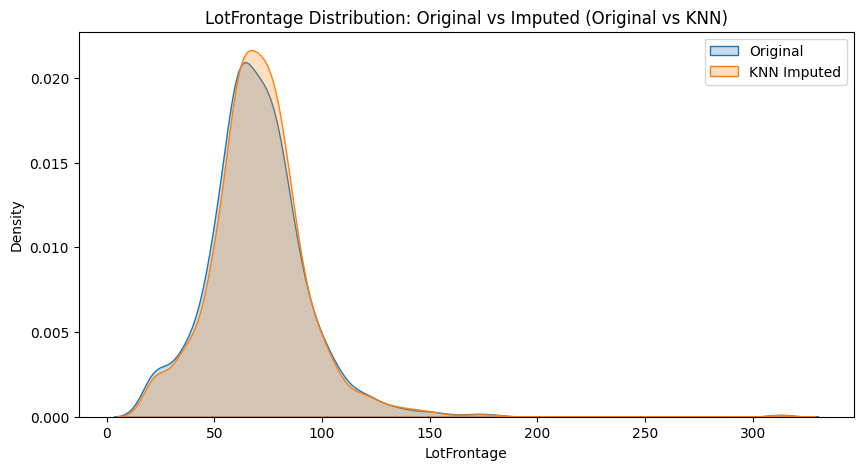

In [99]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
# sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
# sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Original vs KNN)")
plt.show()
# Focus on the original and KNN-imputed distributions.


### Regression Imputation (Advanced)

Regression imputation uses a predictive model to estimate missing values from related features.
It can capture linear relationships but may introduce bias if the predictor set (columns used in prediction) is incomplete.


- Regression imputation replaces missing data by predicting the missing values using a statistical model based on other related variables. It preserves the relationship between variables and utilizes all available data. However, it overestimates correlation and artificially reduces dataset variance.

- Pros
    
    Preserves relationships: It uses existing correlations between variables to make educated, logical guesses for the missing values.
    
    Better than simple methods: It provides more accurate estimates than simply replacing missing values with a mean or median.
    
    Keeps sample size: It avoids deleting rows with missing data (which causes a loss of statistical power).

- Cons
    
    Artificial data reduction: Imputed values fall perfectly on a straight regression line. This reduces data variance (spread) and makes the dataset appear artificially uniform.
    
    Overstates precision: Because it creates a "perfect" fit without error, the correlations between variables are exaggerated, which can make your analysis look more significant than it really is.
    
    Risk of bias: If the underlying data relationship is non-linear, the predictions will be incorrect and biased.

- When to Use

    Data is Missing at Random (MAR): Use this method only when missing data has a known, systematic relationship with other columns in your dataset.
    
    Minor missingness: Apply it when a variable only has a small percentage of missing values (less than 5% to 10%).
    
    For a single baseline guess: Use it when you need to quickly fill in blanks to run a basic predictive model, provided you understand the variance will be slightly skewed (smaller). The model predicts the exact point on the regression line (y = mx + c).  Because these new points have zero residual variance (they don't "bounce" at all), the overall standard deviation of your dataset becomes smaller and narrower. This makes your data look more consistent and precise than it actually is, which can lead to overconfident results.
    
    Avoid when exact variance matters: If you need to make accurate statistical inferences or p-values, use Stochastic Regression Imputation (which adds a random error term) or Multiple Imputation instead.

In [101]:
from sklearn.linear_model import LinearRegression
# Use a linear model to predict missing LotFrontage values.


In [102]:
df_reg = df_drop_manyMissing_lowCorrWithTarget_MultiColl.copy()
# Work on a separate copy so the result can be compared with other imputation strategies.


In [104]:
# drop all the NA rows from LotFrontage to create a training set for the regression model
train_data = df_reg.dropna(subset=["LotFrontage"])  # rows where LotFrontage is observed
train_data


,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [105]:
# Only the NA rows in LotFrontage in the test set dataframe
test_data = df_reg[df_reg["LotFrontage"].isnull()]
# Train the regression imputer on rows with observed LotFrontage and predict for missing rows.
test_data

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
7,RL,NaN,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,...,TA,TA,Y,235,204,228,0,WD,Normal,200000
12,RL,NaN,12968,Pave,IR2,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,140,0,0,176,WD,Normal,144000
14,RL,NaN,10920,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,...,TA,TA,Y,0,213,176,0,WD,Normal,157000
16,RL,NaN,11241,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,NAmes,...,TA,TA,Y,0,0,0,0,WD,Normal,149000
24,RL,NaN,8246,Pave,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,406,90,0,0,WD,Normal,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,RL,NaN,12546,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,...,TA,TA,Y,0,0,99,0,WD,Normal,182900
1431,RL,NaN,4928,Pave,IR1,Lvl,AllPub,Inside,Gtl,NPkVill,...,TA,TA,Y,0,60,0,0,WD,Normal,143750
1441,RM,NaN,4426,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,149,0,0,0,WD,Normal,149300
1443,RL,NaN,8854,Pave,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,...,Fa,Po,P,0,98,0,40,WD,Normal,121000


In [106]:
train_data.info()


<class 'pandas.DataFrame'>
Index: 1201 entries, 0 to 1459
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1201 non-null   str    
 1   LotFrontage    1201 non-null   float64
 2   LotArea        1201 non-null   int64  
 3   Street         1201 non-null   str    
 4   LotShape       1201 non-null   str    
 5   LandContour    1201 non-null   str    
 6   Utilities      1201 non-null   str    
 7   LotConfig      1201 non-null   str    
 8   LandSlope      1201 non-null   str    
 9   Neighborhood   1201 non-null   str    
 10  Condition1     1201 non-null   str    
 11  Condition2     1201 non-null   str    
 12  BldgType       1201 non-null   str    
 13  HouseStyle     1201 non-null   str    
 14  OverallQual    1201 non-null   int64  
 15  YearBuilt      1201 non-null   int64  
 16  YearRemodAdd   1201 non-null   int64  
 17  RoofStyle      1201 non-null   str    
 18  RoofMatl       1201 non-

In [107]:
target_coorelation_ml = train_data.select_dtypes(include=[np.number]).corr()['LotFrontage'].abs()
target_coorelation_ml
# Assess which numeric predictors have the strongest relationship with LotFrontage.


LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
2ndFlrSF         0.080177
GrLivArea        0.402797
BsmtFullBath     0.100949
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr     0.006069
Fireplaces       0.266639
GarageCars       0.285691
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
ScreenPorch      0.041383
SalePrice        0.351799
Name: LotFrontage, dtype: float64

In [110]:
# Here, the columns are hardcoded based on the correlation analysis. 
# In practice, you do like we have done here for dropping columns using multicollinearity,
# you would programmatically select predictors based on their correlation with the target variable and possibly other criteria like missingness or domain knowledge.
# All the knowledge that we have used there, will be applicable here too for selecting predictors for the regression imputer.
X_train = train_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]]
y_train = train_data["LotFrontage"]
# Choose predictors that are likely to explain variation in LotFrontage.


In [111]:
reg = LinearRegression()
# A linear regression model is simple and interpretable for imputation.


In [112]:
reg.fit(X_train, y_train)
# Fit the regression model using rows with observed LotFrontage.


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,-1.5 , 0.01, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['LotArea','OverallQual','TotalBsmtSF','GrLivArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,39.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [113]:
reg.coef_
# Review the learned coefficients to understand feature influence.


array([ 8.90135199e-04, -1.49550808e+00,  1.24430130e-02,  1.16904327e-02])

- Standard regression imputation usually requires "complete" predictor columns to work. If your predictors (the columns you are using to guess the missing value) also have NaNs, the standard math breaks down because the regression equation cannot calculate a result with a "null" input.Depending on how you handle it, one of three things will happen:

- 1. The "Chain Reaction" (Data Loss)

    If you use basic software defaults, the model will likely perform Listwise Deletion.
    
    The Result: It will skip any row where any of the required predictors are missing. If Column A is missing in Row 1, and Column B is missing in Row 2, you lose both rows from your training set.
    
    The Risk: You could end up with a very tiny "complete" dataset that doesn't accurately represent your whole population.

- 2. The "Catch-22" (Stalling)

    You cannot use Column A to predict Column B if Column A is also missing. To solve this, you need a multi-step approach called Iterative Imputation (often known as MICE - Multivariate Imputation by Chained Equations).
    
    Placeholder Fill: All NaNs in all columns are temporarily filled with a simple "guess" like the mean or median.
    
    Iterative Refinement: The model then picks Column A and "re-predicts" it using the placeholder values in the other columns.
    
    Cycle: It repeats this for every column, one by one, updating its "guesses" each time until the values stabilize.

- 3. The "Silent Failure" 
    
    (Bias)If you just drop the rows with missing predictors, your final model might become biased. For example, if low-income individuals are more likely to have "NaN" for both their savings account and their home value, dropping those rows entirely means your model only learns about wealthy individuals.
    
- Recommendation

    If your NaNs are scattered across different columns and rows, do not use simple regression imputation.Use the IterativeImputer in Scikit-Learn (Python) or the mice package (R). These are designed specifically to handle the "NaNs in predictors" problem by cycling through the variables.

In [114]:
test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]].info()
# Verify that predictor columns are available and numeric for the missing rows.
# Here luckily all the predictior columns are having no NaN values, so we can proceed to predict LotFrontage for these rows.
# If there would be NaN values in any of the predictor columns, we would need to handle those missing values before making predictions, either by imputation or by dropping those rows, depending on the context and the amount of missing data.


<class 'pandas.DataFrame'>
Index: 259 entries, 7 to 1446
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LotArea      259 non-null    int64
 1   OverallQual  259 non-null    int64
 2   TotalBsmtSF  259 non-null    int64
 3   GrLivArea    259 non-null    int64
dtypes: int64(4)
memory usage: 10.1 KB


In [115]:
df_reg["LotFrontage"].isnull().head(10)
# Confirm the positions of missing LotFrontage values before imputation.


0    False
1    False
2    False
3    False
4    False
5    False
6    False
7     True
8    False
9    False
Name: LotFrontage, dtype: bool

In [117]:
df_reg.loc[df_reg["LotFrontage"].isnull(), "LotFrontage"].to_frame()

,LotFrontage
7,NaN
12,NaN
14,NaN
16,NaN
24,NaN
...,...
1429,NaN
1431,NaN
1441,NaN
1443,NaN


In [118]:
df_reg.loc[df_reg["LotFrontage"].isnull(), "LotFrontage"] = reg.predict(test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]])
# Replace missing values with the regression predictions for LotFrontage based on the selected predictors.


In [119]:
compare_imputation(df_drop_manyMissing_lowCorrWithTarget_MultiColl, df_reg, "LotFrontage").head(10)
# Inspect the exact values that were imputed by the regression model.


Missing indices for each column: {'LotFrontage': [7, 12, 14, 16, 24, 31, 42, 43, 50, 64, 66, 76, 84, 95, 100, 104, 111, 113, 116, 120, 126, 131, 133, 136, 147, 149, 152, 153, 160, 166, 169, 170, 177, 180, 186, 191, 203, 207, 208, 214, 218, 221, 234, 237, 244, 249, 269, 287, 288, 293, 307, 308, 310, 319, 328, 330, 335, 342, 346, 347, 351, 356, 360, 361, 364, 366, 369, 370, 375, 384, 392, 393, 404, 405, 412, 421, 426, 447, 452, 457, 458, 459, 465, 470, 484, 490, 496, 516, 518, 529, 537, 538, 539, 541, 545, 559, 560, 564, 569, 580, 593, 610, 611, 612, 616, 623, 626, 641, 645, 660, 666, 668, 672, 679, 682, 685, 687, 690, 706, 709, 714, 720, 721, 726, 734, 745, 746, 751, 757, 770, 783, 785, 789, 791, 794, 811, 816, 817, 822, 828, 840, 845, 851, 853, 855, 856, 859, 865, 868, 879, 882, 893, 900, 904, 908, 911, 917, 925, 927, 928, 929, 939, 941, 944, 953, 961, 967, 975, 980, 983, 988, 996, 997, 1003, 1006, 1017, 1018, 1024, 1030, 1032, 1033, 1035, 1037, 1041, 1045, 1057, 1059, 1064, 1077, 1084

,Before,After
7,NaN,76.480215
12,NaN,65.575403
14,NaN,70.486403
16,NaN,64.762909
24,NaN,64.943935
31,NaN,69.263614
42,NaN,60.980342
43,NaN,62.848844
50,NaN,69.936893
64,NaN,74.307034


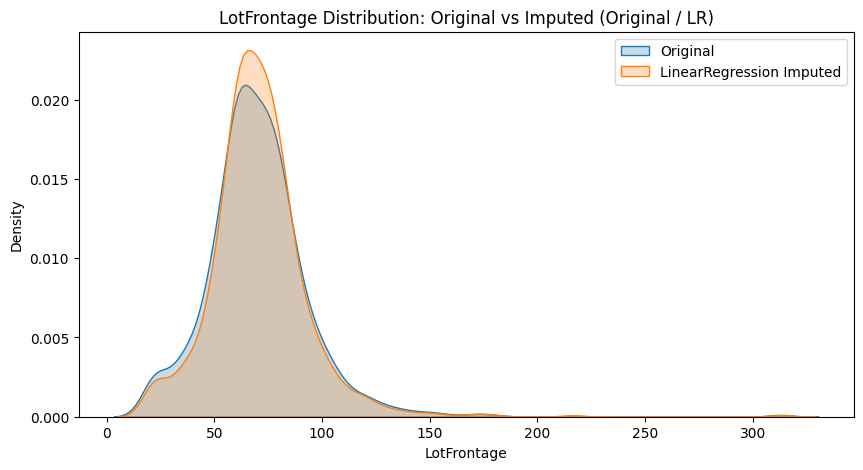

In [121]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df_drop_manyMissing_lowCorrWithTarget_MultiColl["LotFrontage"], label="Original", fill=True)
# sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
sns.kdeplot(df_reg["LotFrontage"], label="LinearRegression Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Original / LR)")
plt.show()
# Compare original distribution with regression-imputed values.


### Filling missing values using Iterative Imputer (MICE)

Iterative Imputer models each incomplete feature as a function of other features and cycles through imputation.
It can be more flexible than single imputation but may be slower and requires numeric data.


- Iterative Imputer handles missing data by modeling each feature as a function of others. It fills gaps sequentially in a round-robin fashion over multiple iterations.Here is a breakdown of its pros, cons, and how to use it.

- Pros

    High Accuracy: Captures complex, multi-variable relationships better than simple mean or median filling.
    
    Flexibility: Works with various machine learning models (e.g., Linear Regression, Random Forests) as the underlying estimator.
    
    Preserves Variance: Maintains the natural distribution and correlation of the dataset well.

- Cons
    
    Slow Speed: Computationally expensive and slow on large datasets due to its cyclic nature.
    
    High Memory: Requires significant RAM because it trains multiple models repeatedly.
    
    Leakage Risk: Can accidentally introduce target leakage if data splits are not handled carefully.

        -- In simple terms, Leakage Risk is like a student seeing the answer key before taking a test. Your model "cheats" by seeing information from the future or from the test set, making it look much smarter during training than it actually is in the real world.When using an Iterative Imputer, this risk happens in two main ways:

            - 1. Train-Test Contamination 
            
                (The most common mistake)If you run the imputer on your entire dataset before splitting it into training and testing sets, you have leaked data.
                
                The Leak: The imputer calculates relationships (like our X₂ = 2 × X₁ example) using every row. This means the values filled in your training data were influenced by information from the test rows.
                
                The Consequence: Your model performs perfectly in your lab because it’s already seen the "patterns" of the test data. But when you give it brand-new data later, it will likely fail.

            - 2. Actual Target Leakage
            
                This happens if you accidentally include the Target variable (the thing you are trying to predict) as a feature inside the imputer.
            
                The Leak: Because Iterative Imputer looks at all columns to fill a gap, it might use your "Final Grade" column to help fill in a missing "Study Hours" value.
                
                The Consequence: You’ve essentially "baked" the answer into your features. The model will learn that "Study Hours" is a perfect predictor of "Final Grade" only because the imputer used the grade to create that feature in the first place.

            - How to Prevent It
            
            - To keep your model honest, follow these rules:
            
                Split First: Always split your data into train and test before you touch any imputer.
                
                Fit only on Train: Run .fit() only on your training data. This ensures the imputer only learns patterns from the allowed "study material".
                
                Transform both: Use .transform() on both sets to fill the gaps, but using the rules learned only from the training set.
                
                Exclude the Target: Never include your actual target y column inside the imputer's input data.

In [ ]:

'''
Toy dataset (missing pattern: each column has one missing):

Row 1: X1=2,    X2=3,    X3=NaN
Row 2: X1=4,    X2=NaN,  X3=3
Row 3: X1=NaN,  X2=7,    X3=5
Row 4: X1=6,    X2=9,    X3=7

Step 0 — Initialization (simple fill, e.g. column means):

Mean(X1 observed) = (2+4+6)/3 = 4.0  => fill X1_row3 = 4.0
Mean(X2 observed) = (3+7+9)/3 = 19/3 ≈ 6.3333 => fill X2_row2 = 6.3333
Mean(X3 observed) = (3+5+7)/3 = 5.0 => fill X3_row1 = 5.0

After init:
Row1: (2, 3, 5)
Row2: (4, 6.3333, 3)
Row3: (4, 7, 5)
Row4: (6, 9, 7)

One iteration (showing OLS math for simple linear regressions with one predictor for clarity).

A) Impute X1 by regressing X1 on X2 using rows where X1 observed (rows 1,2,4).

Regression model: X1 ≈ a + b * X2
Compute:
 mean_X2 = (3 + 6.3333 + 9)/3 = 6.11111
 mean_X1 = (2 + 4 + 6)/3 = 4.0

 Cov(X2,X1) = Σ(x2_i - mean_X2)(x1_i - mean_X1)
    = (-3.1111)(-2) + (0.2222)(0) + (2.8889)(2) = 6.2222 + 0 + 5.7778 = 12.0

 Var(X2) = Σ(x2_i - mean_X2)^2 = 9.6790 + 0.0494 + 8.3457 = 18.0741

 b = Cov/Var ≈ 12.0 / 18.0741 ≈ 0.664
 a = mean_X1 - b*mean_X2 ≈ 4.0 - 0.664*6.11111 ≈ -0.0556

 Predict X1_row3 (X2=7): X1_pred = a + b*7 ≈ -0.0556 + 0.664*7 ≈ 4.5924
 Update X1_row3 := 4.5924

B) Impute X2 by regressing X2 on X1 using rows where X2 observed (rows 1,3,4).
Use updated X1 for row3.

Model: X2 ≈ a2 + b2 * X1
 mean_X1 = (2 + 4.5924 + 6)/3 = 4.1975
 mean_X2 = (3 + 7 + 9)/3 = 6.3333

 Cov(X1,X2) = 7.3249 + 0.2633 + 4.8070 ≈ 12.3952
 Var(X1) = 4.8270 + 0.1560 + 3.2491 ≈ 8.2321

 b2 ≈ 12.3952 / 8.2321 ≈ 1.5056
 a2 ≈ mean_X2 - b2*mean_X1 ≈ 6.3333 - 1.5056*4.1975 ≈ 0.0153

 Predict X2_row2 (X1=4): X2_pred ≈ 0.0153 + 1.5056*4 ≈ 6.0377
 Update X2_row2 := 6.0377

C) Impute X3 by regressing X3 on X1 using rows where X3 observed (rows 2,3,4).
Use latest X1 values.

Model: X3 ≈ a3 + b3 * X1
 mean_X1 = (4 + 4.5924 + 6)/3 = 4.8641
 mean_X3 = (3 + 5 + 7)/3 = 5.0

 Cov(X1,X3) = 1.7283 + 0 + 2.2717 = 4.0000
 Var(X1) = 0.7467 + 0.0738 + 1.2902 = 2.1107

 b3 ≈ 4.0 / 2.1107 ≈ 1.8957
 a3 ≈ 5.0 - 1.8957*4.8641 ≈ -4.220

 Predict X3_row1 (X1=2): X3_pred ≈ -4.220 + 1.8957*2 ≈ -0.4286
 Update X3_row1 := -0.4286

Result after one full cycle:
Row1: X1=2,      X2=3,      X3≈-0.4286
Row2: X1=4,      X2≈6.0377, X3=3
Row3: X1≈4.5924, X2=7,      X3=5
Row4: X1=6,      X2=9,      X3=7

Repeat: next iteration uses these updated values as input; regress again per variable (often using all other columns as predictors), update missing entries, and continue until changes fall below a tolerance or a max number of iterations.

Notes / math formulas used:
 - Univariate OLS slope: b = Σ(xi - x̄)(yi - ȳ) / Σ(xi - x̄)^2
 - Intercept: a = ȳ - b x̄
 - With multivariate predictors, coefficients β = (XᵀX)^{-1} Xᵀy (normal equations).

Practical points:
 - MICE cycles through variables: each regression uses the latest imputed values for other variables.
 - Optionally add a random draw from the residual distribution when predicting (stochastic regression imputation) to reflect uncertainty.
 - Stop when imputations converge or after fixed iterations.
 '''

In [122]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
# Enable and import the experimental iterative imputer.


In [123]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")
# Reload the original dataset to demonstrate MICE on a fresh copy.


In [128]:
cols_to_use = ["LotFrontage", "LotArea", "OverallQual", "OverallCond", "1stFlrSF", "GrLivArea", "GarageYrBlt", "MasVnrArea"]
# Select numeric columns that are likely to help predict missing LotFrontage values.

df[cols_to_use].info()
# Check the selected numeric columns and identify missing values in the subset.


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
 2   OverallQual  1460 non-null   int64  
 3   OverallCond  1460 non-null   int64  
 4   1stFlrSF     1460 non-null   int64  
 5   GrLivArea    1460 non-null   int64  
 6   GarageYrBlt  1379 non-null   float64
 7   MasVnrArea   1452 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 91.4 KB


In [129]:
df_subset = df[cols_to_use].copy()
# Work on a copy of the selected subset.


In [130]:
iter_imput = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=10)
# Use linear regression as the model for each feature's imputation step.


In [131]:
df_subset_imputed_values = iter_imput.fit_transform(df_subset)
# Fit the iterative imputer and generate completed numeric values.


In [132]:
df_subset_imputed_values

array([[6.500e+01, 8.450e+03, 7.000e+00, ..., 1.710e+03, 2.003e+03,
        1.960e+02],
       [8.000e+01, 9.600e+03, 6.000e+00, ..., 1.262e+03, 1.976e+03,
        0.000e+00],
       [6.800e+01, 1.125e+04, 7.000e+00, ..., 1.786e+03, 2.001e+03,
        1.620e+02],
       ...,
       [6.600e+01, 9.042e+03, 7.000e+00, ..., 2.340e+03, 1.941e+03,
        0.000e+00],
       [6.800e+01, 9.717e+03, 5.000e+00, ..., 1.078e+03, 1.950e+03,
        0.000e+00],
       [7.500e+01, 9.937e+03, 5.000e+00, ..., 1.256e+03, 1.965e+03,
        0.000e+00]], shape=(1460, 8))

In [133]:
df_subset[cols_to_use] = df_subset_imputed_values
# Replace the original subset with the imputed results.


In [134]:
df_subset.info()
# Verify that the missing values are now filled.


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1460 non-null   float64
 1   LotArea      1460 non-null   float64
 2   OverallQual  1460 non-null   float64
 3   OverallCond  1460 non-null   float64
 4   1stFlrSF     1460 non-null   float64
 5   GrLivArea    1460 non-null   float64
 6   GarageYrBlt  1460 non-null   float64
 7   MasVnrArea   1460 non-null   float64
dtypes: float64(8)
memory usage: 91.4 KB
